In [1]:
# Cek RAM tersedia
import shutil
total, used, free = shutil.disk_usage('/content')
print(f'Free space: {free // (2**30)} GB')

Free space: 69 GB


In [2]:
!pip install pillow_heif -q

from google.colab import drive
drive.mount('/content/drive')

import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

print('✅ Library siap!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 66.3 MB/s eta 0:00:00
Mounted at /content/drive
✅ Library siap!


In [3]:
secondary_path = '/content/drive/MyDrive/guava_sekunder'
primary_path   = '/content/drive/MyDrive/Data_Nirna_primer_compressed'

print('=== DATASET SEKUNDER ===')
for cls in sorted(os.listdir(secondary_path)):
    p = os.path.join(secondary_path, cls)
    if os.path.isdir(p):
        print(f'  {cls}: {len(os.listdir(p))} gambar')

print('\n=== DATASET PRIMER ===')
for cls in sorted(os.listdir(primary_path)):
    p = os.path.join(primary_path, cls)
    if os.path.isdir(p):
        print(f'  {cls}: {len(os.listdir(p))} gambar')

=== DATASET SEKUNDER ===
  anthracnose: 10921 gambar
  healthy: 11000 gambar
  multiple: 11009 gambar
  scorch: 10678 gambar
  yld: 11000 gambar

=== DATASET PRIMER ===
  anthracnose: 100 gambar
  healthy: 100 gambar
  multiple: 100 gambar
  scorch: 100 gambar
  yld: 100 gambar


In [4]:
try:
    from pillow_heif import register_heif_opener
    register_heif_opener()
    print('pillow_heif loaded.')
except ImportError:
    print('pillow_heif tidak ada, skip konversi HEIC.')

def convert_heic_to_jpg(folder):
    converted = 0
    for root, dirs, files in os.walk(folder):
        for file in files:
            if file.lower().endswith('.heic'):
                path = os.path.join(root, file)
                try:
                    img = Image.open(path).convert('RGB')
                    new_path = path.replace('.heic', '.jpg').replace('.HEIC', '.jpg')
                    img.save(new_path, 'JPEG', quality=95)
                    os.remove(path)
                    converted += 1
                except Exception as e:
                    print(f'  Error konversi {file}: {e}')
    print(f'  Selesai konversi {converted} file HEIC.')

convert_heic_to_jpg(primary_path)
print('✅ Konversi selesai!')

pillow_heif loaded.
  Selesai konversi 0 file HEIC.
✅ Konversi selesai!


In [5]:
output_sampling  = '/content/dataset_fiks_sampling'
sample_per_class = 500

# Hapus dulu kalau sudah ada
if os.path.exists(output_sampling):
    shutil.rmtree(output_sampling)
os.makedirs(output_sampling)

print('=== SAMPLING SEKUNDER ===')
for cls in os.listdir(secondary_path):
    class_path = os.path.join(secondary_path, cls)
    if not os.path.isdir(class_path):
        continue

    images  = [f for f in os.listdir(class_path)
               if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    sampled = random.sample(images, min(sample_per_class, len(images)))

    target = os.path.join(output_sampling, cls)
    os.makedirs(target, exist_ok=True)

    for img in sampled:
        shutil.copy(os.path.join(class_path, img), os.path.join(target, img))

    print(f'  {cls}: {len(sampled)} gambar')

print('\n✅ Sampling selesai!')

=== SAMPLING SEKUNDER ===
  yld: 500 gambar
  scorch: 500 gambar
  multiple: 500 gambar
  healthy: 500 gambar
  anthracnose: 500 gambar

✅ Sampling selesai!


In [6]:
import os
import numpy as np
from PIL import Image, ImageEnhance, ImageFilter
import random

primary_path = '/content/drive/MyDrive/Data_Nirna_primer_compressed'
TARGET       = 100

def augment_image(img):
    img = img.copy()

    # 1. Flip horizontal
    if random.random() > 0.5:
        img = img.transpose(Image.FLIP_LEFT_RIGHT)

    # 2. Rotasi ringan -25 s/d +25 derajat
    angle = random.uniform(-25, 25)
    img = img.rotate(angle, expand=False, fillcolor=(255, 255, 255))

    # 3. Brightness — simulasi perbedaan cahaya
    img = ImageEnhance.Brightness(img).enhance(random.uniform(0.7, 1.4))

    # 4. Contrast
    img = ImageEnhance.Contrast(img).enhance(random.uniform(0.8, 1.3))

    # 5. Saturation
    img = ImageEnhance.Color(img).enhance(random.uniform(0.8, 1.3))

    # 6. Sharpness
    img = ImageEnhance.Sharpness(img).enhance(random.uniform(0.8, 1.5))

    # 7. Random crop + resize (simulasi zoom)
    w, h   = img.size
    mx, my = int(w * random.uniform(0.0, 0.12)), int(h * random.uniform(0.0, 0.12))
    left   = random.randint(0, mx)
    top    = random.randint(0, my)
    right  = w - random.randint(0, mx)
    bottom = h - random.randint(0, my)
    img    = img.crop((left, top, right, bottom)).resize((w, h), Image.LANCZOS)

    # 8. Slight blur (50%) — simulasi fokus kamera berbeda
    if random.random() > 0.5:
        img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.3, 0.8)))

    return img

print(f'Target per class: {TARGET} gambar')
print('=' * 45)

# Check if the primary_path exists before proceeding
if not os.path.exists(primary_path):
    print(f"Error: Direktori '{primary_path}' tidak ditemukan. Pastikan Google Drive sudah terpasang dan path sudah benar.")
else:
    for cls in sorted(os.listdir(primary_path)):
        class_path = os.path.join(primary_path, cls)
        if not os.path.isdir(class_path):
            continue

        images  = [f for f in os.listdir(class_path)
                   if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        current = len(images)

        if current >= TARGET:
            print(f'  ✅ {cls}: {current} gambar — sudah cukup, skip')
            continue

        needed = TARGET - current
        print(f'  🔄 {cls}: {current} gambar → perlu tambah {needed}...')

        generated = 0
        attempts  = 0

        # Handle case where there are no existing images to augment from
        if not images and needed > 0:
            print(f"    ⚠️ Warning: Tidak ada gambar di '{class_path}' untuk diaugmentasi. Tidak bisa menambah gambar.")
            continue

        while generated < needed:
            src_path = os.path.join(class_path, random.choice(images))
            try:
                img = Image.open(src_path).convert('RGB')
                aug = augment_image(img)
                save_name = f'aug_{generated+1:04d}_{os.path.basename(src_path)}'
                aug.save(os.path.join(class_path, save_name), 'JPEG', quality=92)
                generated += 1
            except Exception as e:
                print(f'    ⚠️ Error saat augmentasi {os.path.basename(src_path)}: {e}')

            attempts += 1
            if attempts > needed * 3: # Prevent infinite loop if augmentation consistently fails
                print(f"    ⚠️ Peringatan: Gagal menghasilkan {needed} gambar setelah {attempts} percobaan. Menghentikan augmentasi untuk kelas ini.")
                break

        total_now = len([f for f in os.listdir(class_path)
                         if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        print(f'     → Selesai: {total_now} gambar (+{generated})')

    print('\n=== HASIL AKHIR DATASET PRIMER ===')
    for cls in sorted(os.listdir(primary_path)):
        class_path = os.path.join(primary_path, cls)
        if not os.path.isdir(class_path):
            continue
        n      = len([f for f in os.listdir(class_path)
                      if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        status = '✅' if n >= TARGET else '⚠️'
        print(f'  {status} {cls}: {n} gambar')

    print('\n✅ Augmentasi selesai!')


Target per class: 100 gambar
  ✅ anthracnose: 100 gambar — sudah cukup, skip
  ✅ healthy: 100 gambar — sudah cukup, skip
  ✅ multiple: 100 gambar — sudah cukup, skip
  ✅ scorch: 100 gambar — sudah cukup, skip
  ✅ yld: 100 gambar — sudah cukup, skip

=== HASIL AKHIR DATASET PRIMER ===
  ✅ anthracnose: 100 gambar
  ✅ healthy: 100 gambar
  ✅ multiple: 100 gambar
  ✅ scorch: 100 gambar
  ✅ yld: 100 gambar

✅ Augmentasi selesai!


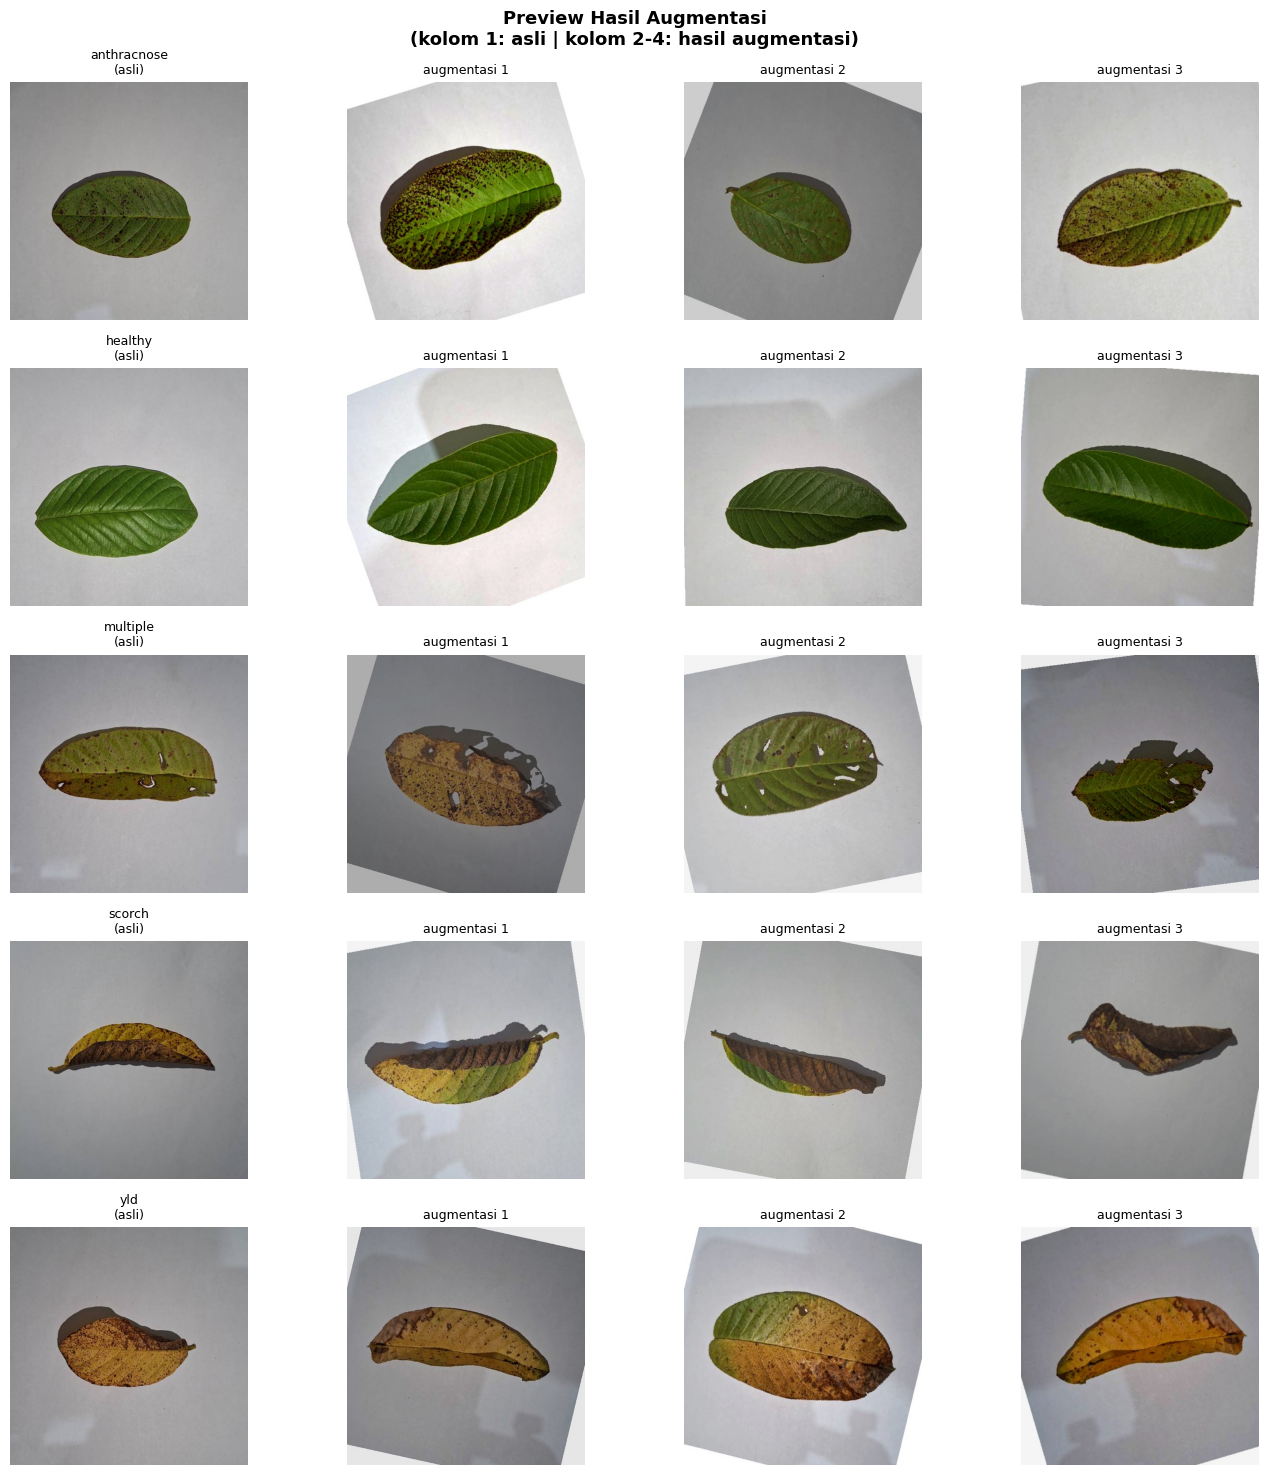

Preview disimpan ke /content/preview_augmentasi.png


In [7]:
import matplotlib.pyplot as plt
from PIL import Image
import os, random

primary_path = '/content/drive/MyDrive/Data_Nirna_primer_compressed'
classes      = sorted([c for c in os.listdir(primary_path)
                        if os.path.isdir(os.path.join(primary_path, c))])

fig, axes = plt.subplots(len(classes), 4, figsize=(14, 3 * len(classes)))
fig.suptitle('Preview Hasil Augmentasi\n(kolom 1: asli | kolom 2-4: hasil augmentasi)',
             fontsize=13, fontweight='bold')

for row, cls in enumerate(classes):
    class_path = os.path.join(primary_path, cls)
    all_imgs   = [f for f in os.listdir(class_path)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    ori_imgs   = [f for f in all_imgs if not f.startswith('aug_')]
    aug_imgs   = [f for f in all_imgs if f.startswith('aug_')]

    # Kolom 1: gambar asli
    src = random.choice(ori_imgs) if ori_imgs else random.choice(all_imgs)
    axes[row][0].imshow(Image.open(os.path.join(class_path, src)).convert('RGB'))
    axes[row][0].set_title(f'{cls}\n(asli)', fontsize=9)
    axes[row][0].axis('off')

    # Kolom 2-4: hasil augmentasi
    samples = random.sample(aug_imgs, min(3, len(aug_imgs)))
    for col, aug_name in enumerate(samples, start=1):
        axes[row][col].imshow(Image.open(os.path.join(class_path, aug_name)).convert('RGB'))
        axes[row][col].set_title(f'augmentasi {col}', fontsize=9)
        axes[row][col].axis('off')

    # Kosongkan kolom sisa
    for col in range(len(samples) + 1, 4):
        axes[row][col].axis('off')

plt.tight_layout()
plt.savefig('/content/preview_augmentasi.png', dpi=150, bbox_inches='tight')
plt.show()
print('Preview disimpan ke /content/preview_augmentasi.png')

In [8]:
import os
import random
import shutil

secondary_path  = '/content/drive/MyDrive/guava_sekunder'
primary_path    = '/content/drive/MyDrive/Data_Nirna_primer_compressed'
output_sampling = '/content/dataset_fiks_sampling' # Folder ini berisi data sekunder yang sudah disampling

# Pastikan output_sampling dibuat jika somehow terhapus, dengan sampling 500 per kelas
if not os.path.exists(output_sampling):
    print('⚠️ dataset_sampling tidak ditemukan, menjalankan sampling ulang...')
    os.makedirs(output_sampling)
    sample_per_class = 500
    for cls in os.listdir(secondary_path):
        class_path = os.path.join(secondary_path, cls)
        if not os.path.isdir(class_path):
            continue
        images  = [f for f in os.listdir(class_path)
                   if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        sampled = random.sample(images, min(sample_per_class, len(images)))
        target  = os.path.join(output_sampling, cls)
        os.makedirs(target, exist_ok=True)
        for img in sampled:
            shutil.copy(os.path.join(class_path, img), os.path.join(target, img))
        print(f'  {cls}: {len(sampled)} gambar (sampling sekunder)')
    print('  Sampling sekunder selesai!')
else:
    print('✅ dataset_sampling (data sekunder) ditemukan.')


# --- Tahap penggabungan data primer (augmentasi) dan sekunder (sampling) ---
combined_source_dir = '/content/dataset_combined_source'

# Hapus direktori gabungan sebelumnya jika ada
if os.path.exists(combined_source_dir):
    shutil.rmtree(combined_source_dir)
os.makedirs(combined_source_dir)
print(f'\nMembuat direktori gabungan: {combined_source_dir}')

# Salin data sekunder (hasil sampling) ke direktori gabungan
print('  Menyalin data sekunder (hasil sampling) ke direktori gabungan...')
for cls in os.listdir(output_sampling):
    class_src_path = os.path.join(output_sampling, cls)
    if not os.path.isdir(class_src_path):
        continue
    class_dest_path = os.path.join(combined_source_dir, cls)
    os.makedirs(class_dest_path, exist_ok=True)
    for img_name in os.listdir(class_src_path):
        shutil.copy(os.path.join(class_src_path, img_name), os.path.join(class_dest_path, img_name))
    print(f'    {cls}: {len(os.listdir(class_src_path))} gambar dari sekunder')


# Salin data primer (hasil augmentasi) ke direktori gabungan
print('  Menyalin data primer (hasil augmentasi) ke direktori gabungan...')
for cls in os.listdir(primary_path): # primary_path sudah berisi gambar yang diaugmentasi
    class_src_path = os.path.join(primary_path, cls)
    if not os.path.isdir(class_src_path):
        continue
    class_dest_path = os.path.join(combined_source_dir, cls)
    os.makedirs(class_dest_path, exist_ok=True) # Pastikan direktori kelas ada
    for img_name in os.listdir(class_src_path):
        # Prepend 'primer_' untuk menghindari bentrokan nama dengan data sekunder
        # dan untuk membedakan sumber jika diperlukan
        shutil.copy(os.path.join(class_src_path, img_name), os.path.join(class_dest_path, 'primer_' + img_name))
    print(f'    {cls}: {len(os.listdir(class_src_path))} gambar dari primer (total {len(os.listdir(class_dest_path))} di gabungan)')

print('\n✅ Penggabungan dataset selesai!')
print(f'Jumlah gambar per kelas di direktori gabungan ({combined_source_dir}):')
for cls in sorted(os.listdir(combined_source_dir)):
    p = os.path.join(combined_source_dir, cls)
    if os.path.isdir(p):
        print(f'  {cls}: {len(os.listdir(p))} gambar')

# --- Sekarang lakukan split train/val/test dari sumber gabungan ---
base_dir_final  = '/content/dataset_final_combined' # Direktori dasar baru untuk split akhir
train_dir = os.path.join(base_dir_final, 'train')
val_dir   = os.path.join(base_dir_final, 'val')
test_dir  = os.path.join(base_dir_final, 'test')

# Hapus dataset gabungan final sebelumnya jika ada
if os.path.exists(base_dir_final):
    shutil.rmtree(base_dir_final)
    print(f'\nMenghapus folder lama: {base_dir_final}')

os.makedirs(train_dir)
os.makedirs(val_dir)
os.makedirs(test_dir)

print('\n=== MELAKUKAN SPLIT TRAIN/VAL/TEST DARI DATA GABUNGAN ===')
train_ratio = 0.70 # 70% untuk training
val_ratio   = 0.15 # 15% untuk validasi
test_ratio  = 0.15 # 15% untuk testing (pastikan jumlah rasio = 1.0)

for cls in os.listdir(combined_source_dir):
    class_path = os.path.join(combined_source_dir, cls)
    if not os.path.isdir(class_path):
        continue

    images = [f for f in os.listdir(class_path)
              if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    random.shuffle(images)

    total_images = len(images)
    train_count  = int(total_images * train_ratio)
    val_count    = int(total_images * val_ratio)
    test_count   = total_images - train_count - val_count # Pastikan semua gambar terpakai

    train_imgs = images[:train_count]
    val_imgs   = images[train_count : train_count + val_count]
    test_imgs  = images[train_count + val_count :]

    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(val_dir,   cls), exist_ok=True)
    os.makedirs(os.path.join(test_dir,  cls), exist_ok=True)

    for img in train_imgs:
        shutil.copy(os.path.join(class_path, img), os.path.join(train_dir, cls, img))
    for img in val_imgs:
        shutil.copy(os.path.join(class_path, img), os.path.join(val_dir,   cls, img))
    for img in test_imgs:
        shutil.copy(os.path.join(class_path, img), os.path.join(test_dir,  cls, img))

    print(f'  {cls} (total {total_images}) → Train: {len(train_imgs)}, Val: {len(val_imgs)}, Test: {len(test_imgs)}')


# Verifikasi akhir
print('\n=== VERIFIKASI AKHIR DATASET GABUNGAN ===')
for nama, path in [('TRAIN', train_dir), ('VAL', val_dir), ('TEST', test_dir)]:
    total = 0
    print(f'\n{nama}:')
    for cls in sorted(os.listdir(path)):
        n = len(os.listdir(os.path.join(path, cls)))
        total += n
        print(f'  {cls}: {n}')
    print(f'  → Total: {total}')

print('\n✅ Dataset final gabungan siap!')

✅ dataset_sampling (data sekunder) ditemukan.

Membuat direktori gabungan: /content/dataset_combined_source
  Menyalin data sekunder (hasil sampling) ke direktori gabungan...
    healthy: 500 gambar dari sekunder
    anthracnose: 500 gambar dari sekunder
    scorch: 500 gambar dari sekunder
    multiple: 500 gambar dari sekunder
    yld: 500 gambar dari sekunder
  Menyalin data primer (hasil augmentasi) ke direktori gabungan...
    yld: 100 gambar dari primer (total 600 di gabungan)
    scorch: 100 gambar dari primer (total 600 di gabungan)
    multiple: 100 gambar dari primer (total 600 di gabungan)
    healthy: 100 gambar dari primer (total 600 di gabungan)
    anthracnose: 100 gambar dari primer (total 600 di gabungan)

✅ Penggabungan dataset selesai!
Jumlah gambar per kelas di direktori gabungan (/content/dataset_combined_source):
  anthracnose: 600 gambar
  healthy: 600 gambar
  multiple: 600 gambar
  scorch: 600 gambar
  yld: 600 gambar

=== MELAKUKAN SPLIT TRAIN/VAL/TEST DARI DA

In [9]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size   = (224, 224)
batch_size = 16

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen  = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# --- Definisikan ulang path untuk dataset gabungan ---
# Pastikan ini sesuai dengan output dari sel sebelumnya (fr6Jc9JUUjPF)
base_dir_final_combined = '/content/dataset_final_combined'
train_dir_combined = os.path.join(base_dir_final_combined, 'train')
val_dir_combined = os.path.join(base_dir_final_combined, 'val')
test_dir_combined = os.path.join(base_dir_final_combined, 'test')

# Pertama, buat train_data untuk mendapatkan canonical class_indices
train_data = train_datagen.flow_from_directory(
    train_dir_combined, # Menggunakan direktori train gabungan
    target_size=img_size,
    batch_size=batch_size, class_mode='categorical'
)

# Dapatkan class_indices dari data training
canonical_class_indices = train_data.class_indices
canonical_classes = sorted(canonical_class_indices, key=canonical_class_indices.get)


val_data = val_datagen.flow_from_directory(
    val_dir_combined, # Menggunakan direktori val gabungan
    target_size=img_size,
    batch_size=batch_size, class_mode='categorical',
    classes=canonical_classes # Menggunakan urutan kelas kanonis
)
test_data = test_datagen.flow_from_directory(
    test_dir_combined, # Menggunakan direktori test gabungan
    target_size=img_size,
    batch_size=batch_size, class_mode='categorical',
    shuffle=False,
    classes=canonical_classes # Menggunakan urutan kelas kanonis
)

print('\nClass index:', train_data.class_indices)
print('Canonical classes (used for all generators):', canonical_classes)
print('train_data.num_classes:', train_data.num_classes)
print('val_data.num_classes:', val_data.num_classes)
print('test_data.num_classes:', test_data.num_classes)

Found 2100 images belonging to 5 classes.
Found 450 images belonging to 5 classes.
Found 450 images belonging to 5 classes.

Class index: {'anthracnose': 0, 'healthy': 1, 'multiple': 2, 'scorch': 3, 'yld': 4}
Canonical classes (used for all generators): ['anthracnose', 'healthy', 'multiple', 'scorch', 'yld']
train_data.num_classes: 5
val_data.num_classes: 5
test_data.num_classes: 5


In [10]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers:
    layer.trainable = False

model_vgg = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(train_data.num_classes, activation='softmax') # Changed from test_data.num_classes to train_data.num_classes
])

model_vgg.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_vgg.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,879,557 (56.76 MB)

 Trainable params: 164,869 (644.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [11]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-6, verbose=1)
]

print('=== PHASE 1: Training Classifier (base frozen) ===')
history_vgg1 = model_vgg.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=callbacks
)

=== PHASE 1: Training Classifier (base frozen) ===
Epoch 1/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 34s 169ms/step - accuracy: 0.5643 - loss: 1.1338 - val_accuracy: 0.8778 - val_loss: 0.4929 - learning_rate: 0.0010
Epoch 2/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 15s 113ms/step - accuracy: 0.8833 - loss: 0.4128 - val_accuracy: 0.9200 - val_loss: 0.2438 - learning_rate: 0.0010
Epoch 3/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 15s 117ms/step - accuracy: 0.9195 - loss: 0.2622 - val_accuracy: 0.9422 - val_loss: 0.1705 - learning_rate: 0.0010
Epoch 4/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 16s 120ms/step - accuracy: 0.9319 - loss: 0.1892 - val_accuracy: 0.9400 - val_loss: 0.1462 - learning_rate: 0.0010
Epoch 5/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 16s 125ms/step - accuracy: 0.9400 - loss: 0.1660 - val_accuracy: 0.9556 - val_loss: 0.1133 - learning_rate: 0.0010
Epoch 6/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 17s 130ms/step - accuracy: 0.9495 - loss: 0.1541 - val_accuracy: 0.9644 - val_loss: 0.0943 - learning_rate: 0.0010
Epoch 7/15
132/132 

In [12]:
# Freeze semua dulu
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze hanya block5 (4 layer terakhir)
for layer in base_model.layers[-4:]:
    layer.trainable = True

model_vgg.compile(
    optimizer=Adam(learning_rate=1e-4),  # LR kecil saat fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('=== PHASE 2: Fine-tuning Block5 VGG16 ===')
history_vgg2 = model_vgg.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=callbacks
)

=== PHASE 2: Fine-tuning Block5 VGG16 ===
Epoch 1/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 32s 190ms/step - accuracy: 0.9576 - loss: 0.1577 - val_accuracy: 0.9844 - val_loss: 0.0395 - learning_rate: 1.0000e-04
Epoch 2/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 21s 158ms/step - accuracy: 0.9757 - loss: 0.0765 - val_accuracy: 0.9822 - val_loss: 0.0479 - learning_rate: 1.0000e-04
Epoch 3/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 21s 156ms/step - accuracy: 0.9910 - loss: 0.0310 - val_accuracy: 0.9333 - val_loss: 0.4919 - learning_rate: 1.0000e-04
Epoch 4/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 20s 154ms/step - accuracy: 0.9748 - loss: 0.1188 - val_accuracy: 0.9889 - val_loss: 0.0378 - learning_rate: 1.0000e-04
Epoch 5/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 20s 154ms/step - accuracy: 0.9919 - loss: 0.0278 - val_accuracy: 0.9867 - val_loss: 0.0444 - learning_rate: 1.0000e-04
Epoch 6/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 21s 156ms/step - accuracy: 0.9976 - loss: 0.0070 - val_accuracy: 0.9822 - val_loss: 0.0657 - learning_rate: 1.0000e-04
Epoc

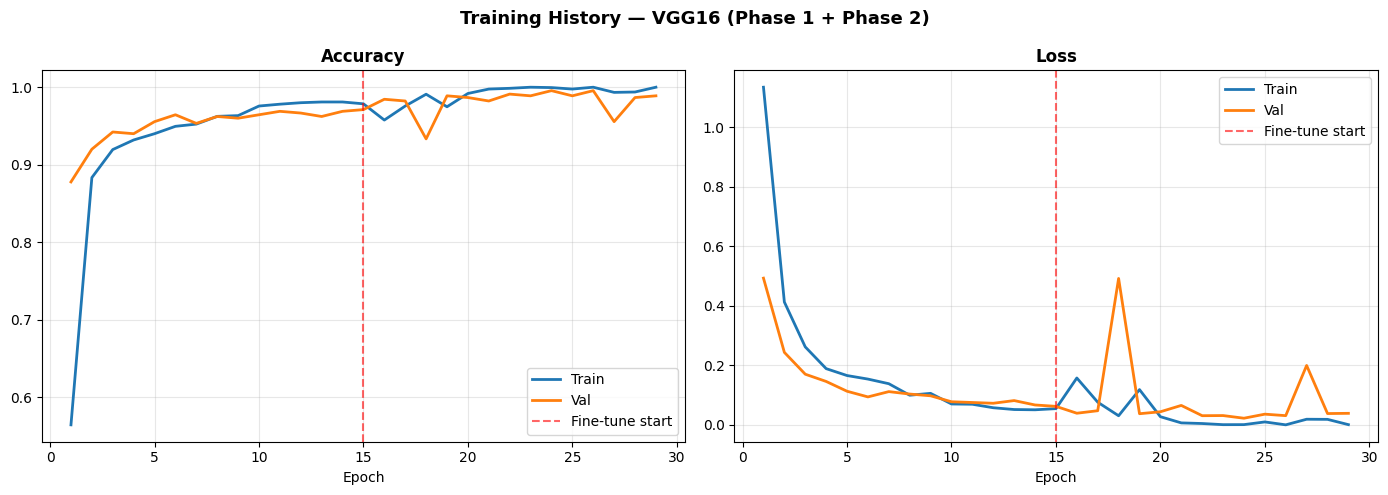


=== EVALUASI TEST SET ===
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - accuracy: 0.9933 - loss: 0.0259

  Test Accuracy : 99.33%
  Test Loss     : 0.0259
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 129ms/step

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

 anthracnose     1.0000    0.9778    0.9888        90
     healthy     0.9783    1.0000    0.9890        90
    multiple     1.0000    0.9889    0.9944        90
      scorch     1.0000    1.0000    1.0000        90
         yld     0.9890    1.0000    0.9945        90

    accuracy                         0.9933       450
   macro avg     0.9935    0.9933    0.9933       450
weighted avg     0.9935    0.9933    0.9933       450



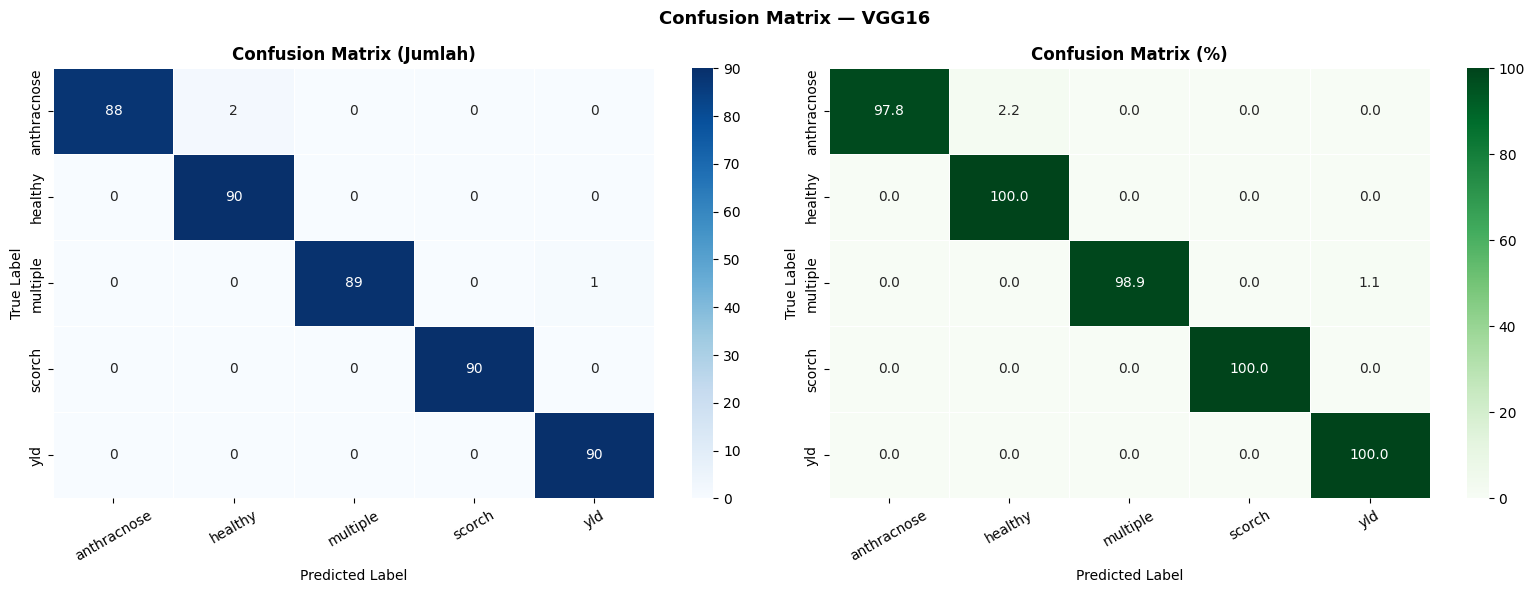


=== AKURASI PER CLASS ===
  anthracnose    : 97.78%
  healthy        : 100.00%
  multiple       : 98.89%
  scorch         : 100.00%
  yld            : 100.00%

✅ Model berhasil disimpan!


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Dynamically get CLASS_NAMES from test_data's class_indices
CLASS_NAMES = sorted(test_data.class_indices, key=test_data.class_indices.get)

# ════════════════════════════════════════════════════════════
# GABUNGKAN HISTORY Phase 1 + Phase 2 (untuk plot)
# ════════════════════════════════════════════════════════════
acc      = history_vgg1.history['accuracy']      + history_vgg2.history['accuracy']
val_acc  = history_vgg1.history['val_accuracy']  + history_vgg2.history['val_accuracy']
loss     = history_vgg1.history['loss']          + history_vgg2.history['loss']
val_loss = history_vgg1.history['val_loss']      + history_vgg2.history['val_loss']
phase2_start = len(history_vgg1.history['accuracy'])

# ── Plot ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, len(acc) + 1)

for ax, (train_m, val_m), title in zip(
    axes,
    [(acc, val_acc), (loss, val_loss)],
    ['Accuracy', 'Loss']
):
    ax.plot(epochs, train_m, label=f'Train', linewidth=2)
    ax.plot(epochs, val_m,   label=f'Val',   linewidth=2)
    ax.axvline(x=phase2_start, color='red', linestyle='--',
               alpha=0.6, label='Fine-tune start')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Training History — VGG16 (Phase 1 + Phase 2)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_history_vgg.png', dpi=150, bbox_inches='tight')
plt.show()

# ════════════════════════════════════════════════════════════
# TESTING
# ════════════════════════════════════════════════════════════
print('\n=== EVALUASI TEST SET ===')
test_loss, test_acc = model_vgg.evaluate(test_data, verbose=1)
print(f'\n  Test Accuracy : {test_acc * 100:.2f}%')
print(f'  Test Loss     : {test_loss:.4f}')

# Prediksi
test_data.reset() # Reset the generator before prediction
y_pred_prob = model_vgg.predict(test_data, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_data.classes  # ganti jika pakai tf.data

# Get unique classes actually present in y_true to adjust target_names
unique_true_classes_indices = np.unique(y_true)
filtered_class_names = [CLASS_NAMES[i] for i in unique_true_classes_indices]

# ── Classification Report ──────────────────────────────────
print('\n=== CLASSIFICATION REPORT ===')
print(classification_report(y_true, y_pred, target_names=filtered_class_names, digits=4))

# ── Confusion Matrix ───────────────────────────────────────
# Specify labels for consistency between y_true/y_pred and target_names
cm     = confusion_matrix(y_true, y_pred, labels=unique_true_classes_indices)
cm_pct = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=filtered_class_names, yticklabels=filtered_class_names,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Confusion Matrix (Jumlah)', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].tick_params(axis='x', rotation=30)

sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Greens',
            xticklabels=filtered_class_names, yticklabels=filtered_class_names,
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion Matrix (%)', fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Confusion Matrix — VGG16', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_vgg.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Akurasi per Class ──────────────────────────────────────
print('\n=== AKURASI PER CLASS ===')
for i, cls_idx in enumerate(unique_true_classes_indices):
    acc_cls = cm[i, i] / cm[i].sum() * 100
    print(f'  {filtered_class_names[i]:<15}: {acc_cls:.2f}%')

# ════════════════════════════════════════════════════════════
# SIMPAN MODEL
# ════════════════════════════════════════════════════════════
model_vgg.save('/content/drive/MyDrive/model_vgg16_final.h5')
print('\n✅ Model berhasil disimpan!')

In [14]:
from tensorflow.keras.applications import MobileNetV2

# MobileNetV2 — arsitektur ringan dari Google (2018) untuk perangkat mobile
# Menggunakan depthwise separable convolution dan inverted residual blocks
# Parameter sangat sedikit (~3.4 juta) — training lebih cepat dari EfficientNetB0
# Akurasi sebelumnya 52.8% kemungkinan karena epoch terlalu sedikit dan lr kurang optimal
base_mn = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze semua layer backbone pada Phase 1
for layer in base_mn.layers:
    layer.trainable = False

# Bangun model dengan backbone MobileNetV2 + classification head
model_mobilenet = models.Sequential([
    base_mn,
    # GlobalAveragePooling2D meratakan output 7x7x1280 MobileNetV2 → vektor 1280
    layers.GlobalAveragePooling2D(),
    # Dense 256 untuk kombinasi fitur dari backbone
    layers.Dense(256, activation='relu'),
    # Dropout 0.5 untuk mencegah overfitting
    layers.Dropout(0.5),
    # Output 5 kelas dengan softmax
    layers.Dense(train_data.num_classes, activation='softmax')
])

# Kompilasi Phase 1: lr=1e-4 (lebih konservatif, cocok untuk MobileNetV2)
model_mobilenet.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('=== Training MobileNetV2 Phase 1 (backbone frozen) ===')
# Phase 1: latih hanya head selama 10 epoch
history_mn1 = model_mobilenet.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=callbacks
)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
=== Training MobileNetV2 Phase 1 (backbone frozen) ===
Epoch 1/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 50s 246ms/step - accuracy: 0.7605 - loss: 0.6939 - val_accuracy: 0.9600 - val_loss: 0.1959 - learning_rate: 1.0000e-04
Epoch 2/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9505 - loss: 0.1775 - val_accuracy: 0.9778 - val_loss: 0.0995 - learning_rate: 1.0000e-04
Epoch 3/10
130/132 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9794 - loss: 0.1053
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9743 - loss: 0.1101 - val_accuracy: 0.9756 - val_loss: 0.0715 - learning_rate: 1.0000e-04
Epoch 4/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.9805 - loss: 0.0779 - val_accuracy: 0.9778 - val_loss: 0.0659 - learning_rate: 3.0000e-05
Epoch 5/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9838 - loss: 0.0664 - val_accuracy: 0.9778 - v

In [15]:
# Unfreeze 20 layer terakhir MobileNetV2 untuk fine-tuning
# Layer terakhir MobileNetV2 berisi inverted residual blocks atas yang mengekstrak
# fitur abstrak tingkat tinggi — perlu diadaptasi ke domain visual daun jambu
for layer in base_mn.layers[-20:]:
    layer.trainable = True

# Kompilasi ulang dengan lr sangat kecil (1e-5) untuk fine-tuning yang hati-hati
# LR kecil mencegah bobot pretrained berubah terlalu drastis
model_mobilenet.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('=== Fine-tuning MobileNetV2 Phase 2 (20 layer terakhir) ===')
# Phase 2: lanjutkan training dengan backbone sebagian terbuka selama 10 epoch
history_mn2 = model_mobilenet.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=callbacks
)


=== Fine-tuning MobileNetV2 Phase 2 (20 layer terakhir) ===
Epoch 1/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 34s 147ms/step - accuracy: 0.8205 - loss: 0.5203 - val_accuracy: 0.9111 - val_loss: 0.2275 - learning_rate: 1.0000e-05
Epoch 2/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9462 - loss: 0.2204 - val_accuracy: 0.9222 - val_loss: 0.2090 - learning_rate: 1.0000e-05
Epoch 3/10
131/132 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9664 - loss: 0.1426
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
132/132 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.9648 - loss: 0.1448 - val_accuracy: 0.9356 - val_loss: 0.1782 - learning_rate: 1.0000e-05
Epoch 4/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.9681 - loss: 0.1278 - val_accuracy: 0.9511 - val_loss: 0.1493 - learning_rate: 3.0000e-06
Epoch 5/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.9705 - loss: 0.1124 - val_accuracy: 0.9644 - val_loss: 0.1260 - learning_rate: 3.0000e-06


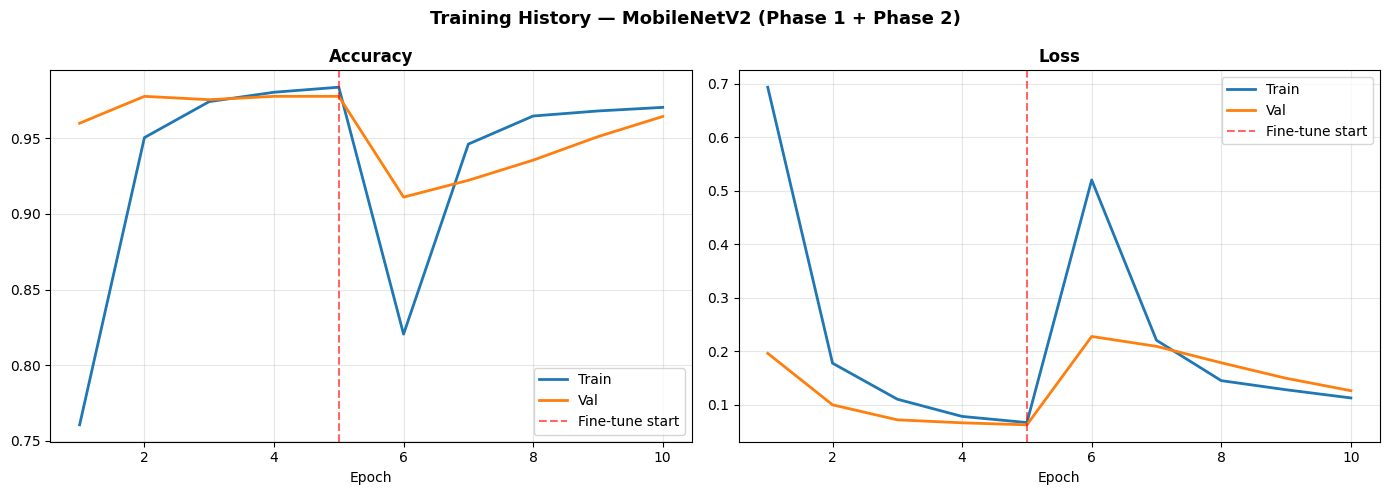


=== EVALUASI TEST SET — MobileNetV2 ===
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9244 - loss: 0.2440

  Test Accuracy : 92.44%
  Test Loss     : 0.2440
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 169ms/step

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

 anthracnose     0.9425    0.9111    0.9266        90
     healthy     0.8165    0.9889    0.8945        90
    multiple     1.0000    0.8444    0.9157        90
      scorch     1.0000    0.8889    0.9412        90
         yld     0.9082    0.9889    0.9468        90

    accuracy                         0.9244       450
   macro avg     0.9334    0.9244    0.9249       450
weighted avg     0.9334    0.9244    0.9249       450



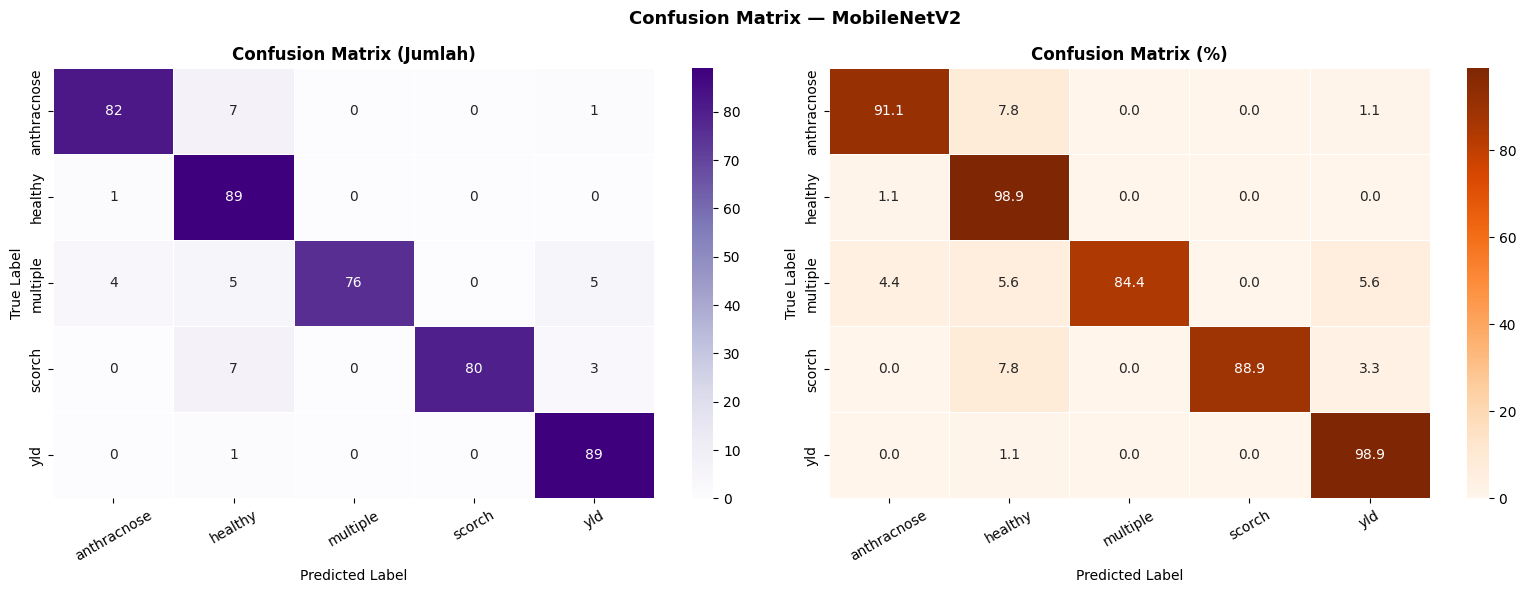


=== AKURASI PER CLASS ===
  anthracnose    : 91.11%
  healthy        : 98.89%
  multiple       : 84.44%
  scorch         : 88.89%
  yld            : 98.89%

✅ Model berhasil disimpan!


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Dynamically get CLASS_NAMES from test_data's class_indices
CLASS_NAMES = sorted(test_data.class_indices, key=test_data.class_indices.get)

# ════════════════════════════════════════════════════════════
# GABUNGKAN HISTORY Phase 1 + Phase 2
# ════════════════════════════════════════════════════════════
acc      = history_mn1.history['accuracy']     + history_mn2.history['accuracy']
val_acc  = history_mn1.history['val_accuracy'] + history_mn2.history['val_accuracy']
loss     = history_mn1.history['loss']         + history_mn2.history['loss']
val_loss = history_mn1.history['val_loss']     + history_mn2.history['val_loss']
phase2_start = len(history_mn1.history['accuracy'])

# ── Plot History ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, len(acc) + 1)

for ax, (train_m, val_m), title in zip(
    axes,
    [(acc, val_acc), (loss, val_loss)],
    ['Accuracy', 'Loss']
):
    ax.plot(epochs, train_m, label='Train', linewidth=2)
    ax.plot(epochs, val_m,   label='Val',   linewidth=2)
    ax.axvline(x=phase2_start, color='red', linestyle='--',
               alpha=0.6, label='Fine-tune start')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Training History — MobileNetV2 (Phase 1 + Phase 2)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_history_mobilenet.png', dpi=150, bbox_inches='tight')
plt.show()

# ════════════════════════════════════════════════════════════
# TESTING
# ════════════════════════════════════════════════════════════
print('\n=== EVALUASI TEST SET — MobileNetV2 ===')
test_data.reset() # Reset the generator before evaluation
test_loss, test_acc = model_mobilenet.evaluate(test_data, verbose=1)
print(f'\n  Test Accuracy : {test_acc * 100:.2f}%')
print(f'  Test Loss     : {test_loss:.4f}')

# Prediksi
test_data.reset() # Reset the generator before prediction
y_pred_prob = model_mobilenet.predict(test_data, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_data.classes  # ganti jika pakai tf.data

# Get unique classes actually present in y_true to adjust target_names
unique_true_classes_indices = np.unique(y_true)
filtered_class_names = [CLASS_NAMES[i] for i in unique_true_classes_indices]

# ── Classification Report ──────────────────────────────────
print('\n=== CLASSIFICATION REPORT ===')
print(classification_report(y_true, y_pred, labels=unique_true_classes_indices, target_names=filtered_class_names, digits=4))

# ── Confusion Matrix ───────────────────────────────────────
# Specify labels for consistency between y_true/y_pred and target_names
cm     = confusion_matrix(y_true, y_pred, labels=unique_true_classes_indices)
cm_pct = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=filtered_class_names, yticklabels=filtered_class_names,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Confusion Matrix (Jumlah)', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].tick_params(axis='x', rotation=30)

sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Oranges',
            xticklabels=filtered_class_names, yticklabels=filtered_class_names,
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion Matrix (%)', fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Confusion Matrix — MobileNetV2', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_mobilenet.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Akurasi per Class ──────────────────────────────────────
print('\n=== AKURASI PER CLASS ===')
for i, cls_idx in enumerate(unique_true_classes_indices):
    acc_cls = cm[i, i] / cm[i].sum() * 100
    print(f'  {filtered_class_names[i]:<15}: {acc_cls:.2f}%')


# ════════════════════════════════════════════════════════════
# SIMPAN MODEL
# ════════════════════════════════════════════════════════════
# model_MobileNetv2.save('/content/drive/MyDrive/model_MobileNetV2_final.h5')
# The variable model_MobileNetv2 is not defined, assuming it should be model_mobilenet
model_mobilenet.save('/content/drive/MyDrive/model_MobileNetV2_final.h5')
print('\n✅ Model berhasil disimpan!')

In [17]:
# ═══════════════════════════════════════════════════════════
# CELL 16 — MobileNetV3Large (VERSI PERBAIKAN)
# ═══════════════════════════════════════════════════════════
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ─── FIX 1: Buat generator khusus V3 dengan preprocess_input ───────────────
# MobileNetV3 WAJIB pakai preprocess_input dari mobilenet_v3
# yang menghasilkan range [-1, +1], bukan rescale=1./255 (range [0,1]).
# train_data, val_data, test_data yang dipakai VGG16/V2 TIDAK cocok untuk V3.
train_datagen_v3 = ImageDataGenerator(preprocessing_function=preprocess_input)
val_datagen_v3   = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen_v3  = ImageDataGenerator(preprocessing_function=preprocess_input)

# Ambil urutan kelas dari train_data yang sudah ada (supaya konsisten)
canonical_classes = sorted(train_data.class_indices, key=train_data.class_indices.get)

train_data_v3 = train_datagen_v3.flow_from_directory(
    train_dir_combined,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    classes=canonical_classes
)
val_data_v3 = val_datagen_v3.flow_from_directory(
    val_dir_combined,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    classes=canonical_classes
)
test_data_v3 = test_datagen_v3.flow_from_directory(
    test_dir_combined,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False,
    classes=canonical_classes
)

print(f'train_data_v3 classes: {train_data_v3.class_indices}')

# ─── FIX 2: include_preprocessing=False ────────────────────────────────────
# MobileNetV3Large punya layer preprocessing internal yang mengasumsikan
# input [0, 255]. Karena kita sudah handle preprocessing di generator,
# set include_preprocessing=False agar tidak terjadi double-processing.
base_mn_v3 = MobileNetV3Large(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3),
    include_preprocessing=False  # FIX: preprocessing sudah di generator
)

# Freeze semua layer backbone pada Phase 1
for layer in base_mn_v3.layers:
    layer.trainable = False

# Bangun model dengan backbone MobileNetV3Large + classification head
# (struktur head identik dengan versi asli)
model_mobilenet_v3 = models.Sequential([
    base_mn_v3,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_data.num_classes, activation='softmax')
])

# ─── FIX 3: Callbacks terpisah dengan patience lebih panjang ───────────────
# V3 lebih kompleks, butuh lebih banyak epoch untuk konvergen.
callbacks_v3 = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=4, min_lr=1e-6, verbose=1)
]

# ─── FIX 4: lr Phase 1 = 1e-3 (bukan 1e-4 yang terlalu konservatif) ───────
model_mobilenet_v3.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('=== Training MobileNetV3Large Phase 1 (backbone frozen) ===')

# Phase 1: latih hanya head — epoch diperbesar ke 15 agar V3 sempat warm-up
history_mn_v3_1 = model_mobilenet_v3.fit(
    train_data_v3,          # FIX: pakai generator khusus V3
    validation_data=val_data_v3,
    epochs=15,              # FIX: dari 10 → 15
    callbacks=callbacks_v3  # FIX: callbacks dengan patience lebih panjang
)

Found 2100 images belonging to 5 classes.
Found 450 images belonging to 5 classes.
Found 450 images belonging to 5 classes.
train_data_v3 classes: {'anthracnose': 0, 'healthy': 1, 'multiple': 2, 'scorch': 3, 'yld': 4}
12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
=== Training MobileNetV3Large Phase 1 (backbone frozen) ===
Epoch 1/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 52s 245ms/step - accuracy: 0.4171 - loss: 1995689.1250 - val_accuracy: 0.5422 - val_loss: 258890.4688 - learning_rate: 0.0010
Epoch 2/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.4752 - loss: 178475.7969 - val_accuracy: 0.5000 - val_loss: 85207.0859 - learning_rate: 0.0010
Epoch 3/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.4395 - loss: 49947.8125 - val_accuracy: 0.4733 - val_loss: 42485.7812 - learning_rate: 0.0010
Epoch 4/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.3971 - loss: 29312.7402 - val_accuracy: 0.4533 - val_loss: 29744.9453 - learning_rate: 0.0010
Epoch 5/15
132/132 ━━

In [18]:
# ═══════════════════════════════════════════════════════════
# CELL 17 — Fine-tuning MobileNetV3Large (VERSI PERBAIKAN)
# ═══════════════════════════════════════════════════════════

# Unfreeze 20 layer terakhir MobileNetV3Large untuk fine-tuning
for layer in base_mn_v3.layers[-20:]:
    layer.trainable = True

# ─── FIX 5: lr Phase 2 = 1e-4 (bukan 1e-5 yang terlalu kecil) ─────────────
# LR 1e-5 membuat model tidak sempat adapt dalam 10 epoch.
model_mobilenet_v3.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('=== Fine-tuning MobileNetV3Large Phase 2 (20 layer terakhir) ===')

# Phase 2: lanjutkan training dengan backbone sebagian terbuka
history_mn_v3_2 = model_mobilenet_v3.fit(
    train_data_v3,          # FIX: tetap pakai generator khusus V3
    validation_data=val_data_v3,
    epochs=15,              # FIX: dari 10 → 15
    callbacks=callbacks_v3
)

=== Fine-tuning MobileNetV3Large Phase 2 (20 layer terakhir) ===
Epoch 1/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 38s 169ms/step - accuracy: 0.3376 - loss: 1.5139 - val_accuracy: 0.4222 - val_loss: 1.6608 - learning_rate: 1.0000e-04
Epoch 2/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.5024 - loss: 1.2706 - val_accuracy: 0.5000 - val_loss: 1.4170 - learning_rate: 1.0000e-04
Epoch 3/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.5667 - loss: 1.1092 - val_accuracy: 0.5178 - val_loss: 1.3879 - learning_rate: 1.0000e-04
Epoch 4/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.6219 - loss: 1.0122 - val_accuracy: 0.5800 - val_loss: 1.1653 - learning_rate: 1.0000e-04
Epoch 5/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.6471 - loss: 0.9387 - val_accuracy: 0.6311 - val_loss: 1.1041 - learning_rate: 1.0000e-04
Epoch 6/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.6810 - loss: 0.8796 - val_accuracy: 0.6622 - val_loss: 1.0184 - learning_rate: 1.


=== EVALUASI TEST SET ===
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7889 - loss: 0.7107

Test Accuracy : 78.89%
Test Loss     : 0.7107
29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 237ms/step

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

 anthracnose       0.91      0.77      0.83        90
     healthy       0.83      0.74      0.78        90
    multiple       0.70      0.76      0.73        90
      scorch       0.89      0.87      0.88        90
         yld       0.68      0.81      0.74        90

    accuracy                           0.79       450
   macro avg       0.80      0.79      0.79       450
weighted avg       0.80      0.79      0.79       450



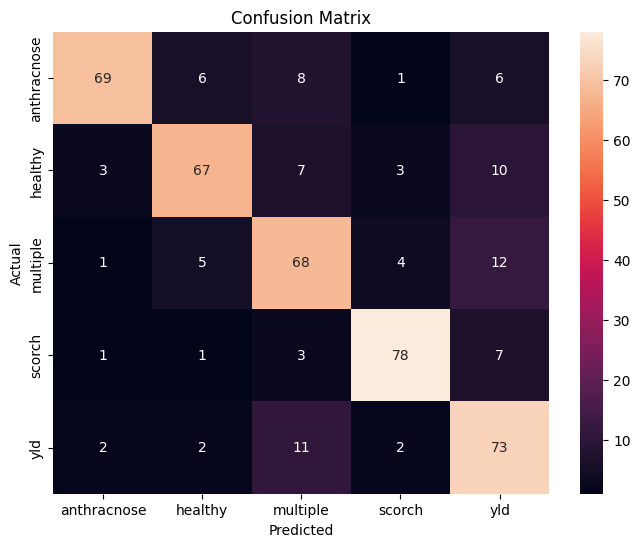


✅ Model berhasil disimpan!


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Ambil nama class dari test_data_v3
CLASS_NAMES = sorted(test_data_v3.class_indices, key=test_data_v3.class_indices.get)

# ================================
# GABUNG HISTORY (PASTIKAN SESUAI CELL SEBELUMNYA)
# ================================
acc      = history_mn_v3_1.history['accuracy']     + history_mn_v3_2.history['accuracy']
val_acc  = history_mn_v3_1.history['val_accuracy'] + history_mn_v3_2.history['val_accuracy']
loss     = history_mn_v3_1.history['loss']         + history_mn_v3_2.history['loss']
val_loss = history_mn_v3_1.history['val_loss']     + history_mn_v3_2.history['val_loss']
phase2_start = len(history_mn_v3_1.history['accuracy'])

# ================================
# EVALUASI
# ================================
print('\n=== EVALUASI TEST SET ===')
test_data_v3.reset()
test_loss, test_acc = model_mobilenet_v3.evaluate(test_data_v3, verbose=1)
print(f'\nTest Accuracy : {test_acc * 100:.2f}%')
print(f'Test Loss     : {test_loss:.4f}')

# Prediksi
test_data_v3.reset()
y_pred_prob = model_mobilenet_v3.predict(test_data_v3, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_data_v3.classes

# Class names
CLASS_NAMES = list(test_data_v3.class_indices.keys())

# ================================
# CLASSIFICATION REPORT
# ================================
print('\n=== CLASSIFICATION REPORT ===')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# ================================
# CONFUSION MATRIX
# ================================
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ================================
# SIMPAN MODEL
# ================================
model_mobilenet_v3.save('/content/drive/MyDrive/model_MobileNetV3_final.h5')
print('\n✅ Model berhasil disimpan!')

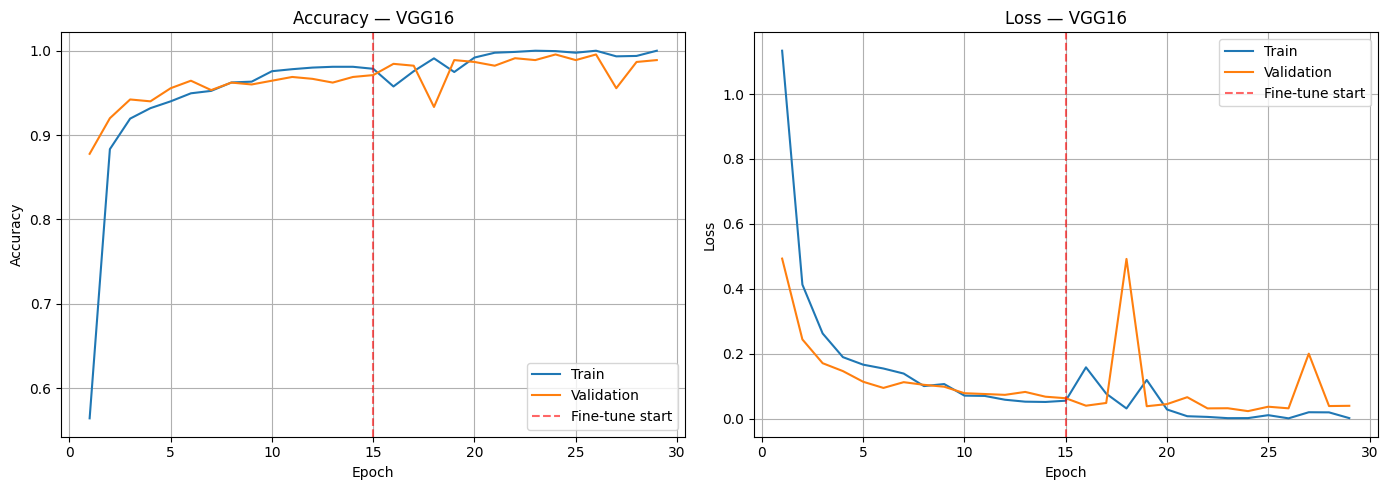

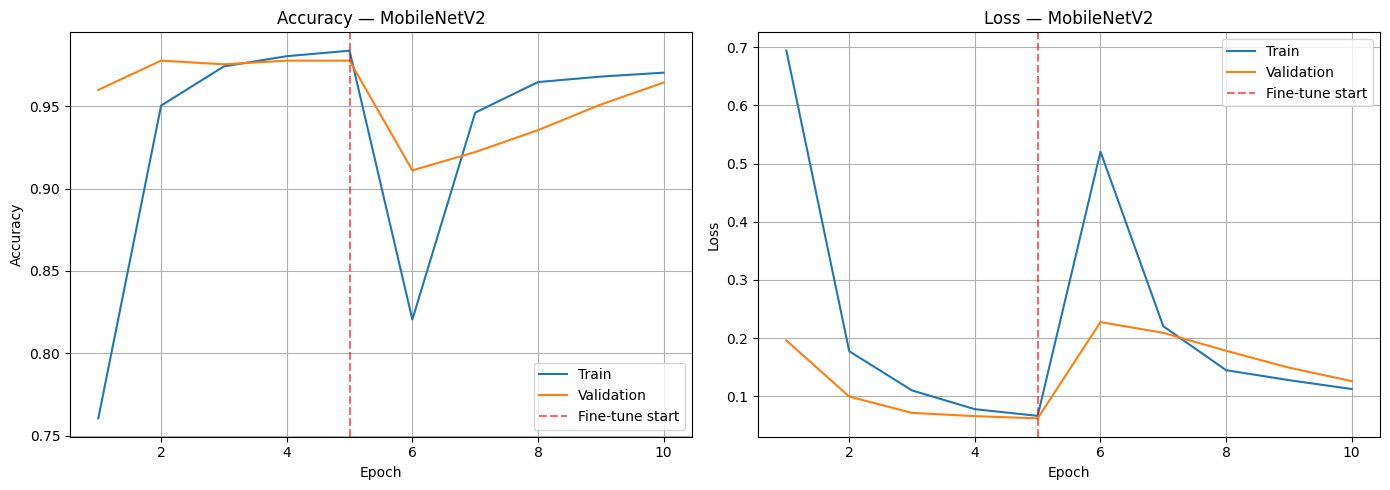

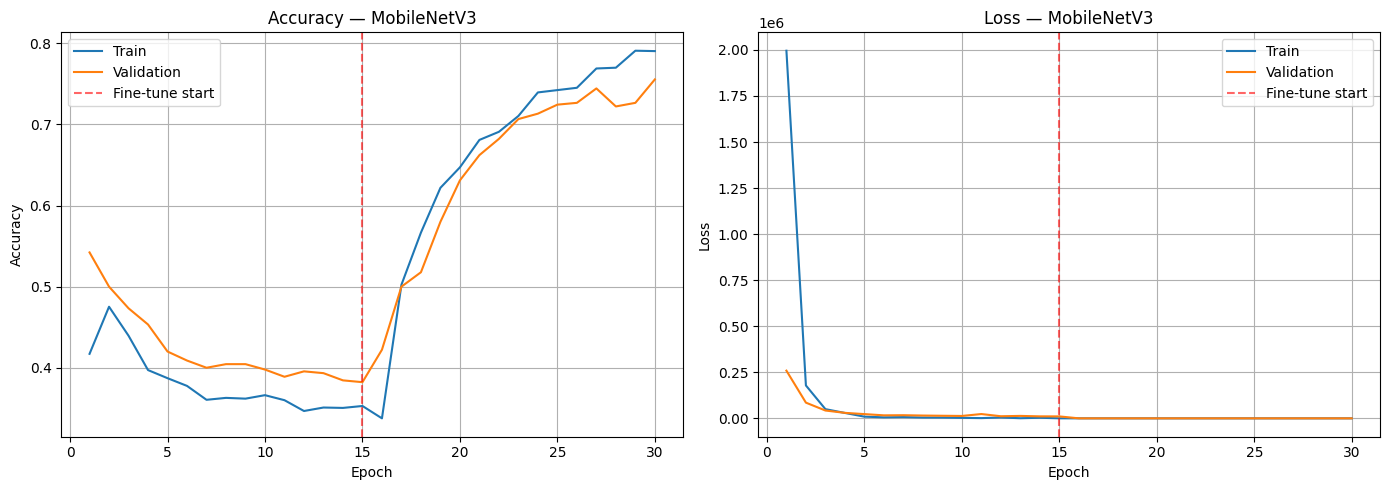

In [20]:
def plot_history(histories, model_name):
    acc, val_acc, loss, val_loss = [], [], [], []

    # Calculate phase2_start if there are multiple histories
    phase2_start = 0
    if isinstance(histories, list) and len(histories) > 1:
        phase2_start = len(histories[0].history['accuracy'])

    for h in (histories if isinstance(histories, list) else [histories]):
        acc      += h.history['accuracy']
        val_acc  += h.history['val_accuracy']
        loss     += h.history['loss']
        val_loss += h.history['val_loss']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(acc) + 1) # Define epochs here for consistent plotting

    ax1.plot(epochs, acc,     label='Train')
    ax1.plot(epochs, val_acc, label='Validation')
    if phase2_start > 0: # Only draw line if there was a phase 2
        ax1.axvline(x=phase2_start, color='red', linestyle='--', alpha=0.6, label='Fine-tune start')
    ax1.set_title(f'Accuracy — {model_name}')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend(); ax1.grid(True)

    ax2.plot(epochs, loss,     label='Train')
    ax2.plot(epochs, val_loss, label='Validation')
    if phase2_start > 0: # Only draw line if there was a phase 2
        ax2.axvline(x=phase2_start, color='red', linestyle='--', alpha=0.6, label='Fine-tune start')
    ax2.set_title(f'Loss — {model_name}')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(True)

    plt.tight_layout()
    plt.savefig(f'/content/history_{model_name.replace(" ","_")}.png', dpi=150)
    plt.show()

plot_history([history_vgg1, history_vgg2], 'VGG16')
plot_history([history_mn1,  history_mn2],  'MobileNetV2')
plot_history([history_mn_v3_1,  history_mn_v3_2],  'MobileNetV3')


EVALUASI: VGG16
Test Loss    : 0.0259
Test Accuracy: 0.9933 (99.3%)

Classification Report:
              precision    recall  f1-score   support

 anthracnose     1.0000    0.9778    0.9888        90
     healthy     0.9783    1.0000    0.9890        90
    multiple     1.0000    0.9889    0.9944        90
      scorch     1.0000    1.0000    1.0000        90
         yld     0.9890    1.0000    0.9945        90

    accuracy                         0.9933       450
   macro avg     0.9935    0.9933    0.9933       450
weighted avg     0.9935    0.9933    0.9933       450



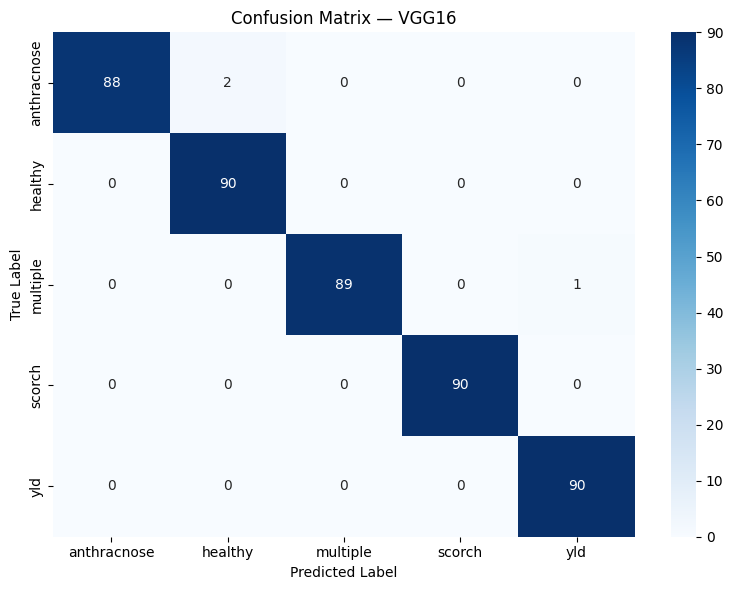


EVALUASI: MobileNetV2
Test Loss    : 0.2440
Test Accuracy: 0.9244 (92.4%)

Classification Report:
              precision    recall  f1-score   support

 anthracnose     0.9425    0.9111    0.9266        90
     healthy     0.8165    0.9889    0.8945        90
    multiple     1.0000    0.8444    0.9157        90
      scorch     1.0000    0.8889    0.9412        90
         yld     0.9082    0.9889    0.9468        90

    accuracy                         0.9244       450
   macro avg     0.9334    0.9244    0.9249       450
weighted avg     0.9334    0.9244    0.9249       450



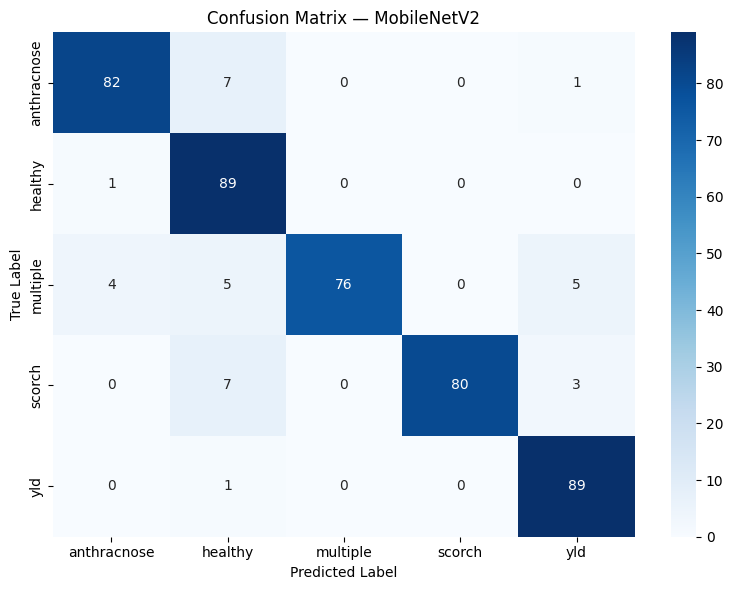


EVALUASI: MobileNetV3
Test Loss    : 0.7107
Test Accuracy: 0.7889 (78.9%)

Classification Report:
              precision    recall  f1-score   support

 anthracnose     0.9079    0.7667    0.8313        90
     healthy     0.8272    0.7444    0.7836        90
    multiple     0.7010    0.7556    0.7273        90
      scorch     0.8864    0.8667    0.8764        90
         yld     0.6759    0.8111    0.7374        90

    accuracy                         0.7889       450
   macro avg     0.7997    0.7889    0.7912       450
weighted avg     0.7997    0.7889    0.7912       450



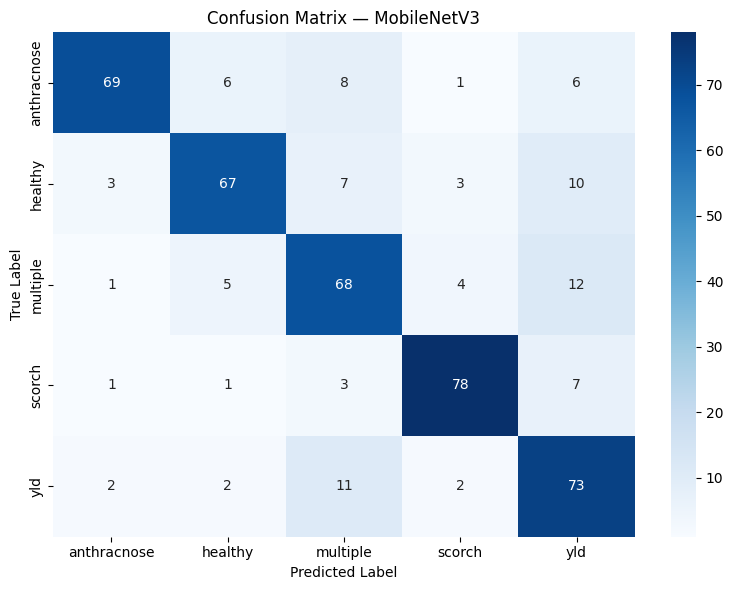

In [21]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def evaluate_model(model, test_data, model_name):
    print(f"\n{'='*50}")
    print(f'EVALUASI: {model_name}')
    print('='*50)

    loss, acc = model.evaluate(test_data, verbose=0)
    print(f'Test Loss    : {loss:.4f}')
    print(f'Test Accuracy: {acc:.4f} ({acc*100:.1f}%)')

    test_data.reset()
    y_pred = np.argmax(model.predict(test_data, verbose=0), axis=1)
    y_true = test_data.classes

    global CLASS_NAMES # Access the global CLASS_NAMES defined earlier (from jnXkrQGyU94S)

    # Get unique classes actually present in y_true
    unique_true_classes_indices = np.unique(y_true)
    filtered_class_names = [CLASS_NAMES[i] for i in unique_true_classes_indices]

    print('\nClassification Report:')
    print(classification_report(y_true, y_pred, labels=unique_true_classes_indices, target_names=filtered_class_names, digits=4, zero_division=0))

    # Specify labels for consistency between y_true/y_pred and target_names for confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=unique_true_classes_indices)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=filtered_class_names, yticklabels=filtered_class_names)
    plt.title(f'Confusion Matrix — {model_name}')
    plt.ylabel('True Label'); plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'/content/cm_{model_name.replace(" ","_")}.png', dpi=150)
    plt.show()
    return acc

acc_vgg          = evaluate_model(model_vgg,           test_data, 'VGG16')
acc_mobilenet    = evaluate_model(model_mobilenet,      test_data, 'MobileNetV2')
acc_mobilenet_v3 = evaluate_model(model_mobilenet_v3, test_data_v3, 'MobileNetV3')

In [22]:
print('\n' + '='*50)
print('RINGKASAN PERBANDINGAN MODEL')
print('='*50)
print(f'  VGG16           Test Accuracy: {acc_vgg*100:.1f}%')
print(f'  MobileNetV2     Test Accuracy: {acc_mobilenet*100:.1f}%')
print(f'  MobileNetV3     Test Accuracy: {acc_mobilenet_v3*100:.1f}%')

scores = {'VGG16': acc_vgg, 'MobileNetV2': acc_mobilenet, 'MobileNetV3': acc_mobilenet_v3}
best_name  = max(scores, key=scores.get)
best_model = {'VGG16': model_vgg, 'MobileNetV2': model_mobilenet, 'MobileNetV3': model_mobilenet_v3}[best_name]

print(f'\n✅ Model terbaik: {best_name} ({scores[best_name]*100:.1f}%)')

save_path = '/content/drive/MyDrive/deep_learning/best_model_guava.h5'
best_model.save(save_path)
print(f'Model disimpan ke: {save_path}')


RINGKASAN PERBANDINGAN MODEL
  VGG16           Test Accuracy: 99.3%
  MobileNetV2     Test Accuracy: 92.4%
  MobileNetV3     Test Accuracy: 78.9%

✅ Model terbaik: VGG16 (99.3%)
Model disimpan ke: /content/drive/MyDrive/deep_learning/best_model_guava.h5
